In [1]:
%matplotlib inline

In [2]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
)

In [5]:
from xgboost import XGBRegressor

In [6]:
RANDOM_STATE = 42
USE_GPU = True
N_COMPONENTS = 20

In [7]:
# ---- 0. Paths ----
DATA_DIR = r"E:\NSU\cse445\EDA attempt3\Dataset\ML dataset"
TRAIN_FILE = f"{DATA_DIR}/ML_train.csv"
TEST_FILE = f"{DATA_DIR}/ML_test.csv"
BERT_FILE = r"E:\NSU\cse445\EDA attempt3\NLP models\embeddings\bert_embeddings.csv"

In [8]:
# ---- 1. Fixed best hyperparameters ----
BEST_PARAMS = {
    "colsample_bytree": 0.9512165066659852,
    "learning_rate": 0.07643904937766527,
    "max_depth": 6,
    "min_child_weight": 7,
    "n_estimators": 459,
    "reg_alpha": 0.0014729254229045347,
    "reg_lambda": 0.845771345696438,
    "subsample": 0.8060762192885254,
}

In [9]:
# ---- 2. Load data + PCA (fixed N=20, fit on train only) ----
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)
bert_raw = pd.read_csv(BERT_FILE)

In [10]:
TARGET_RAW = "target_usd"
TARGET_LOG = "log_target"
DROP_FROM_X = ["id", "target_usd", "log_target", "goal_usd"]

In [11]:
train_ids = set(train_df["id"])
feature_cols = [c for c in bert_raw.columns if c != "id"]
train_mask = bert_raw["id"].isin(train_ids)

In [12]:
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
pca.fit(bert_raw.loc[train_mask, feature_cols])
reduced_all = pca.transform(bert_raw[feature_cols])
reduced_cols = [f"bert_pca_{i}" for i in range(N_COMPONENTS)]
reduced_df = pd.DataFrame(reduced_all, columns=reduced_cols)
reduced_df.insert(0, "id", bert_raw["id"].values)

In [13]:
merged_train = train_df.merge(reduced_df, on="id", how="left")
merged_test = test_df.merge(reduced_df, on="id", how="left")

In [14]:
X_train = merged_train.drop(columns=DROP_FROM_X, errors="ignore")
X_test = merged_test.drop(columns=DROP_FROM_X, errors="ignore")
y_train = merged_train[TARGET_LOG].copy()
y_test_full = merged_test[TARGET_LOG].copy()
actual_usd_full = merged_test[TARGET_RAW].to_numpy()

In [15]:
assert list(X_train.columns) == list(X_test.columns)

In [16]:
# ---- 3. Fit model ONCE on full training data ----
model = XGBRegressor(
    objective="reg:squarederror", eval_metric="rmse",
    tree_method="hist", device="cuda" if USE_GPU else "cpu",
    random_state=RANDOM_STATE,
    **BEST_PARAMS,
)
model.fit(X_train, y_train)
pred_log_full = model.predict(X_test)
pred_usd_full = np.clip(np.expm1(pred_log_full), a_min=0, a_max=None)

In [17]:
print(f"Model fitted. Test set size: {len(y_test_full)}")

Model fitted. Test set size: 4000


In [18]:
# ---- 4. Evaluation helper ----
def evaluate_subset(mask, label):
    y_log = y_test_full[mask].to_numpy()
    p_log = pred_log_full[mask]
    a_usd = actual_usd_full[mask]
    p_usd = pred_usd_full[mask]

    mae_log = mean_absolute_error(y_log, p_log)
    mse_log = mean_squared_error(y_log, p_log)
    rmse_log = np.sqrt(mse_log)
    r2_log = r2_score(y_log, p_log)

    mae_usd = mean_absolute_error(a_usd, p_usd)
    mse_usd = mean_squared_error(a_usd, p_usd)
    rmse_usd = np.sqrt(mse_usd)
    r2_usd = r2_score(a_usd, p_usd)

    rmsle = np.sqrt(mean_squared_log_error(a_usd, p_usd))

    return {
        "Variant": label,
        "N_Test_Rows": mask.sum(),
        "Pct_Removed": round(100 * (1 - mask.sum() / len(mask)), 2),
        "MAE_log": mae_log, "MSE_log": mse_log, "RMSE_log": rmse_log, "R2_log": r2_log,
        "MAE_USD": mae_usd, "MSE_USD": mse_usd, "RMSE_USD": rmse_usd, "R2_USD": r2_usd,
        "RMSLE": rmsle,
    }

In [19]:
# ---- 5. Build outlier-removal masks ----
results = []

In [20]:
# Full test set (baseline)
full_mask = np.ones(len(actual_usd_full), dtype=bool)
results.append(evaluate_subset(full_mask, "Full (baseline)"))

In [21]:
# Percentile-based: drop top 1%
p99 = np.percentile(actual_usd_full, 99)
mask_p1 = actual_usd_full <= p99
results.append(evaluate_subset(mask_p1, "Drop top 1% (percentile)"))

In [22]:
# Percentile-based: drop top 5%
p95 = np.percentile(actual_usd_full, 95)
mask_p5 = actual_usd_full <= p95
results.append(evaluate_subset(mask_p5, "Drop top 5% (percentile)"))

In [23]:
# IQR-based
q1, q3 = np.percentile(actual_usd_full, [25, 75])
iqr = q3 - q1
iqr_upper = q3 + 1.5 * iqr
mask_iqr = actual_usd_full <= iqr_upper
results.append(evaluate_subset(mask_iqr, "IQR-based (Q3+1.5*IQR)"))

In [24]:
# ---- 6. Results table ----
results_df = pd.DataFrame(results)
results_df = results_df[[
    "Variant", "N_Test_Rows", "Pct_Removed",
    "MAE_log", "MSE_log", "RMSE_log", "R2_log",
    "MAE_USD", "MSE_USD", "RMSE_USD", "R2_USD", "RMSLE"
]]
print("\n" + "="*70)
print("ABLATION RESULTS: Outlier sensitivity of R2_USD")
print("="*70)
print(results_df)


ABLATION RESULTS: Outlier sensitivity of R2_USD
                    Variant  N_Test_Rows  Pct_Removed   MAE_log   MSE_log  \
0           Full (baseline)         4000         0.00  1.115845  2.275488   
1  Drop top 1% (percentile)         3960         1.00  1.104012  2.233832   
2  Drop top 5% (percentile)         3800         5.00  1.091117  2.194218   
3    IQR-based (Q3+1.5*IQR)         3515        12.12  1.098940  2.238052   

   RMSE_log    R2_log       MAE_USD       MSE_USD      RMSE_USD    R2_USD  \
0  1.508472  0.757791  14587.044370  9.713670e+09  98557.950385  0.176912   
1  1.494601  0.753077   7114.116094  5.520197e+08  23495.098608  0.289254   
2  1.481289  0.740542   3888.784771  9.001254e+07   9487.493717 -0.140278   
3  1.496012  0.719325   2664.995691  4.624927e+07   6800.681664 -1.140609   

      RMSLE  
0  1.506474  
1  1.492564  
2  1.479148  
3  1.493719  


In [25]:
results_df.to_csv("outlier_ablation_results.csv", index=False)
print("\nSaved: outlier_ablation_results.csv")


Saved: outlier_ablation_results.csv


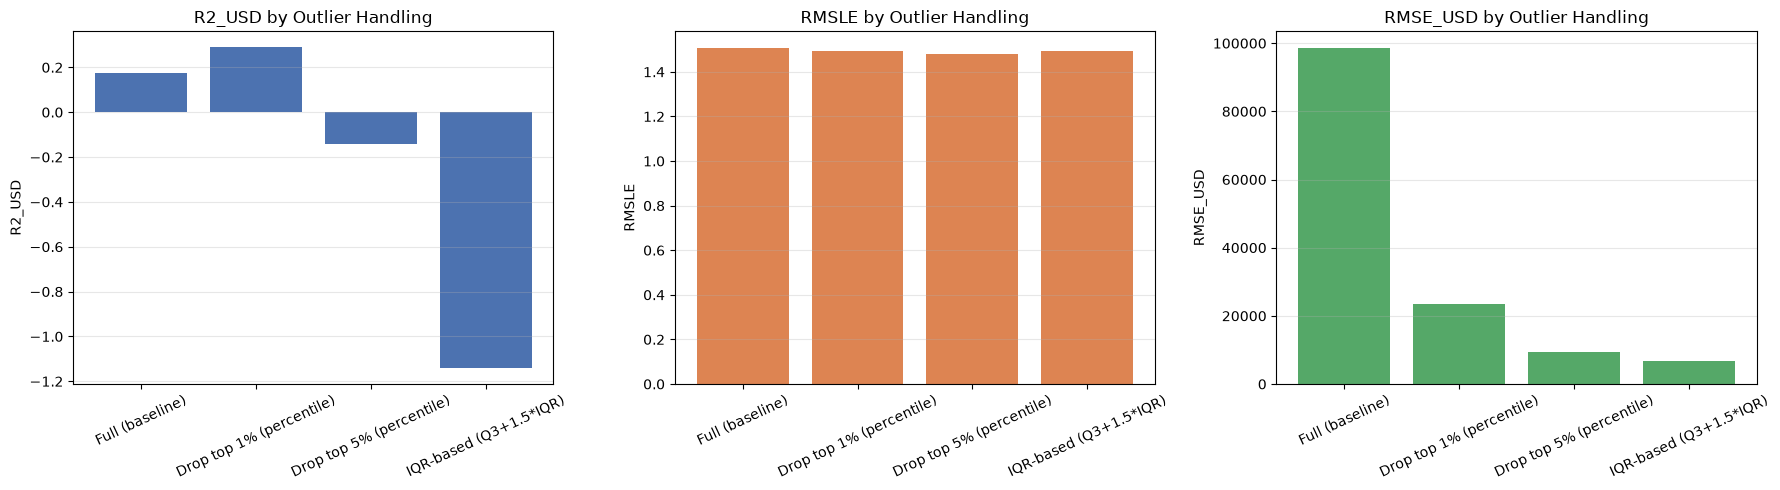

Saved: outlier_ablation_plot.png


In [31]:
# ---- 7. Plot (single cell) ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(results_df["Variant"], results_df["R2_USD"], color="#4C72B0")
axes[0].set_ylabel("R2_USD")
axes[0].set_title("R2_USD by Outlier Handling")
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(True, alpha=0.3, axis="y")
axes[1].bar(results_df["Variant"], results_df["RMSLE"], color="#DD8452")
axes[1].set_ylabel("RMSLE")
axes[1].set_title("RMSLE by Outlier Handling")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(True, alpha=0.3, axis="y")
axes[2].bar(results_df["Variant"], results_df["RMSE_USD"], color="#55A868")
axes[2].set_ylabel("RMSE_USD")
axes[2].set_title("RMSE_USD by Outlier Handling")
axes[2].tick_params(axis="x", rotation=25)
axes[2].grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("outlier_ablation_plot.png", dpi=150)
plt.show()
print("Saved: outlier_ablation_plot.png")

<Figure size 640x480 with 0 Axes>

Saved: outlier_ablation_plot.png
